# Practice 1 – FashionMNIST Classification
## Loss, Optimizer và Training Loop
- Cell 13: Setup (import + load data thật + model)
- Cell 14: Loss Function
- Cell 15: Optimizer
- Cell 16: Training Function
- Cell 17: Run Training
- Cell 18: Plot Loss


### Cell 13 — Setup (Import, Data, Model)

In [1]:
import sys
sys.path.append("../../")

from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from Practice_1.src.data import create_dataloaders, CLASS_NAMES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset, test_dataset, train_loader, test_loader = create_dataloaders(
    data_dir="./data",
    batch_size=64
)
print("Data đã sẵn sàng — train:", len(train_dataset), "test:", len(test_dataset))

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

model = NeuralNetwork().to(device)
print(model)

Data đã sẵn sàng — train: 60000 test: 10000
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [2]:
criterion = nn.CrossEntropyLoss()

### Cell 15 — Optimizer

In [3]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Cell 16 — Training Function
Quy trình: `Batch → Forward → Prediction → Loss → zero_grad() → Backward → Gradient → optimizer.step()`

In [ ]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    loss_history = []

    for epoch in range(num_epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)             
            loss = criterion(outputs, labels)     
            optimizer.zero_grad()                
            loss.backward()                       
            optimizer.step()                       

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        loss_history.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

    return loss_history

### Cell 17 — Run Training

In [5]:
num_epochs = 10
loss_history = train_model(model, train_loader, criterion, optimizer, num_epochs)

Epoch [1/10] - Loss: 0.5578
Epoch [2/10] - Loss: 0.3922
Epoch [3/10] - Loss: 0.3492
Epoch [4/10] - Loss: 0.3257
Epoch [5/10] - Loss: 0.3066
Epoch [6/10] - Loss: 0.2896
Epoch [7/10] - Loss: 0.2783
Epoch [8/10] - Loss: 0.2653
Epoch [9/10] - Loss: 0.2567
Epoch [10/10] - Loss: 0.2463


### Cell 18 — Plot Loss

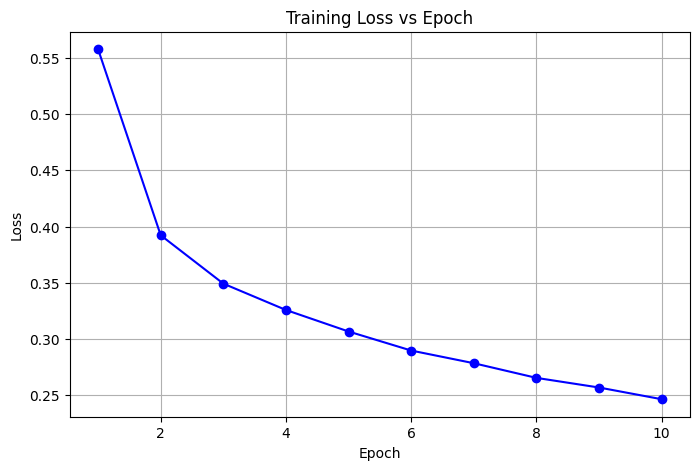

In [6]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', color='b')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()